### Track linear nonlinear delta in good sessions

In [1]:
# import alles
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from sklearn.ensemble import RandomForestClassifier
from ibl_info.prepare_data_pid import (
    cleaned_regions_flags,
    get_new_cinc_intervals,
    prepare_ephys_data,
)
from ibl_info.utils import (
    alternate_discretize,
    compute_mutual_information,
    compute_pid,
    compute_trivariate_mi,
    FIRING_RATE,
    discretize,
    discretize_keeping_zeros,
    equipopulated_binning,
)
import os
import concurrent.futures
import functools
import random
from ibl_info.utils import check_config
from glob import glob

In [ ]:
# with open(
#     "../data/generated/decoded/good_decoding_sessions/selective_decomposition_VISp_stim_decoder_good_decoder_sessions_only.pkl",
#     "rb",
# ) as f:
#     visp_data = pkl.load(f)

In [3]:
data_files = glob("../data/generated/decoded/good_decoding_sessions/*.pkl")

In [41]:
def plot_data(congruent_deltas, incongruent_deltas, region_name, filter=False):
    congruent_deltas = np.array(congruent_deltas)
    incongruent_deltas = np.array(incongruent_deltas)
    all_data = np.hstack((congruent_deltas[:, 0:2], incongruent_deltas[:, 0:2]))
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    sns.boxenplot(
        all_data, showfliers=False, ax=ax[0], palette=["#4D79FF", "#4D79FF", "#FF4D4D", "#FF4D4D"]
    )
    sns.swarmplot(all_data, ax=ax[0])

    for idx in range(len(all_data)):
        ax[0].plot(
            [0, 1], [all_data[idx, 0], all_data[idx, 1]], color="gray", linestyle="--", alpha=0.6
        )
        ax[0].plot(
            [2, 3], [all_data[idx, 2], all_data[idx, 3]], color="gray", linestyle="--", alpha=0.6
        )

    ax[1].bar(
        np.arange(2),
        [np.mean(congruent_deltas[:, -1]), np.mean(incongruent_deltas[:, -1])],
        tick_label=["Congruent", "Incongruent"],
        edgecolor="k",
        yerr=[np.std(congruent_deltas[:, -1] / 2), np.std(incongruent_deltas[:, -1] / 2)],
        capsize=2,
        color=["#4D79FF", "#FF4D4D"],
    )

    ax[0].set_xticks([0, 1, 2, 3])
    ax[0].set_xticklabels(["Linear", "Non-linear", "Linear", "Non-linear"])
    ax[0].set_ylabel("Accuracy")
    ax[1].set_ylabel("Accuracy Difference")

    ax[0].spines["right"].set_visible(False)
    ax[0].spines["top"].set_visible(False)
    ax[1].spines["right"].set_visible(False)
    ax[1].spines["top"].set_visible(False)

    fig.suptitle(region_name)
    plt.tight_layout()

In [61]:
global_congruent_deltas = []
global_incongruent_deltas = []
for file in data_files:
    region_name = file.rsplit("_stim_decoder")[0].rsplit("_")[-1]
    with open(file, "rb") as f:
        data = pkl.load(f)
    congruent_deltas = []
    incongruent_deltas = []
    for eids in data.keys():
        congruent_deltas.append(np.mean(data[eids]["congruent_delta"], axis=0))
        incongruent_deltas.append(data[eids]["incongruent_delta"])
    # plot_data(congruent_deltas, incongruent_deltas, region_name)
    global_congruent_deltas.append(np.mean(congruent_deltas, axis=0))
    global_incongruent_deltas.append(np.mean(incongruent_deltas, axis=0))

In [62]:
global_congruent_deltas = np.vstack(global_congruent_deltas)
global_incongruent_deltas = np.vstack(global_incongruent_deltas)

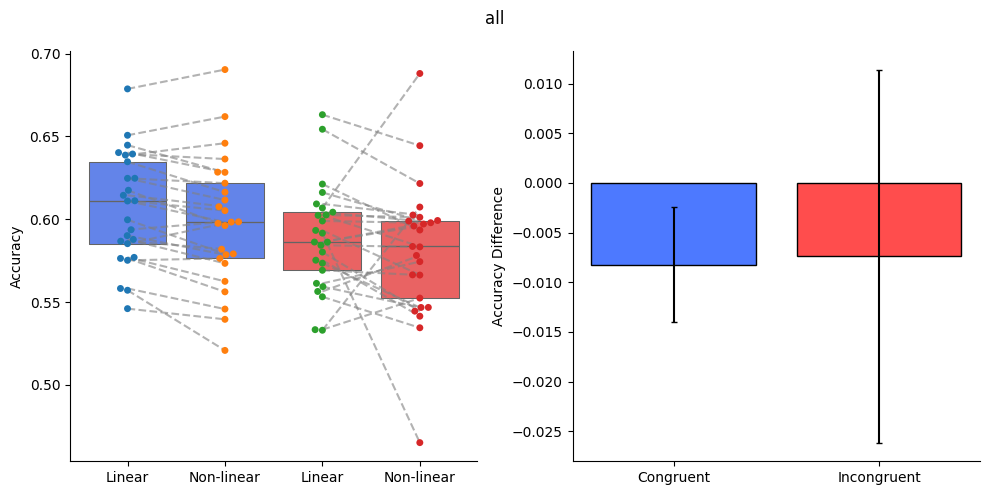

In [63]:
plot_data(global_congruent_deltas, global_incongruent_deltas, "all", filter=False)

### try out our new decoder function

In [10]:
# import numpy as np
# from sklearn.model_selection import KFold, GridSearchCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC
# from sklearn.pipeline import Pipeline
# from sklearn.datasets import make_classification, make_moons


# def compare_classifiers_cross_val(X, y, scale_features=True):

#     N_SPLITS_OUTER = 5
#     N_SPLITS_INNER = 3

#     linear_svm = SVC(kernel="linear", random_state=42)
#     linear_svm_params = {"classifier__C": [0.01, 0.1, 1, 10, 100]}
#     rbf_svm = SVC(kernel="rbf", random_state=42)
#     rbf_svm_params = {
#         "classifier__C": [0.1, 1, 10, 100],
#         "classifier__gamma": ["scale", 1, 0.1, 0.01],
#     }

#     outer_cv = KFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=42)
#     inner_cv = KFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=42)

#     linear_svm_scores = []
#     rbf_svm_scores = []

#     for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):

#         X_train_outer, X_test_outer = X[train_idx], X[test_idx]
#         y_train_outer, y_test_outer = y[train_idx], y[test_idx]
#         steps = []
#         if scale_features:
#             steps.append(("scaler", StandardScaler()))
#         linear_svm_pipeline = Pipeline(steps + [("classifier", linear_svm)])
#         rbf_svm_pipeline = Pipeline(steps + [("classifier", rbf_svm)])

#         grid_search_linear_svm = GridSearchCV(
#             estimator=linear_svm_pipeline,
#             param_grid=linear_svm_params,
#             cv=inner_cv,
#             scoring="accuracy",
#         )
#         grid_search_linear_svm.fit(X_train_outer, y_train_outer)
#         best_linear_svm = grid_search_linear_svm.best_estimator_

#         grid_search_rbf_svm = GridSearchCV(
#             estimator=rbf_svm_pipeline, param_grid=rbf_svm_params, cv=inner_cv, scoring="accuracy"
#         )
#         grid_search_rbf_svm.fit(X_train_outer, y_train_outer)
#         best_rbf_svm = grid_search_rbf_svm.best_estimator_

#         linear_svm_accuracy = best_linear_svm.score(X_test_outer, y_test_outer)
#         rbf_svm_accuracy = best_rbf_svm.score(X_test_outer, y_test_outer)

#         linear_svm_scores.append(linear_svm_accuracy)
#         rbf_svm_scores.append(rbf_svm_accuracy)

#     return {"LinearSVM": linear_svm_scores, "RbfSVM": rbf_svm_scores}

# X_sample, y_sample = make_moons(n_samples=500, noise=0.3, random_state=42)


# X_sample[:, 0] *= 10
# print(f"Sample data shape: {X_sample.shape}")
# print(f"Sample labels shape: {y_sample.shape}")
# scores_scaled = compare_classifiers_cross_val(X_sample, y_sample, scale_features=True)
# scores_scaled_no = compare_classifiers_cross_val(X_sample, y_sample, scale_features=False)

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from ibl_info.decoder_pid import subsampled, compare_classifiers_cross_val
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from sklearn.ensemble import RandomForestClassifier
from ibl_info.prepare_data_pid import (
    cleaned_regions_flags,
    get_new_cinc_intervals,
    prepare_ephys_data,
)
from ibl_info.utils import (
    alternate_discretize,
    compute_mutual_information,
    compute_pid,
    compute_trivariate_mi,
    FIRING_RATE,
    discretize,
    discretize_keeping_zeros,
    equipopulated_binning,
)
import os
import concurrent.futures
import functools
import random
from ibl_info.utils import check_config

warnings.filterwarnings("ignore")
# all these annoying warnings are because of the M4 chip

In [5]:
one = ONE()
df_parq = pd.read_parquet("../data/external/stimside_stage2.pqt")
unit_df = bwm_units(one)

subject_id = "CSH_ZAD_022"
eid = "a82800ce-f4e3-4464-9b80-4c3d6fade333"
session_id = eid
pids, probes = one.eid2pid(session_id)
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
    spikes, clusters = merge_probes(
        [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
    )
else:
    spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
trials = trials[mask]

intervals, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(
    trials, "stim"
)

binned_spikes, actual_regions, n_units, cluster_uuids_list = prepare_ephys_data(
    spikes, clusters, intervals, ["LGd"], minimum_units=5
)  # this returns all neurons from a single region that pass qc
# however, it is in trials x neurons

spike_data = binned_spikes[0].T

congruent_target = target_variable[congruent_flags]
incongruent_target = target_variable[incongruent_flags]

congruent_spikes = spike_data[:, congruent_flags]
incongruent_spikes = spike_data[:, incongruent_flags]

information_pickle = {}
trial_count = np.zeros((3))

trial_count[0] = intervals.shape[0]
trial_count[1] = np.sum(congruent_flags)
trial_count[2] = np.sum(incongruent_flags)
information_pickle["neurons"] = spike_data.shape[0]
information_pickle["trials"] = trial_count

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01
Region found LGd, 67


In [6]:
all_data = compare_classifiers_cross_val(
    trial_types=target_variable, neural_activity=spike_data.T, scale_features=True
)

LogReg vs GradientBoosting


In [12]:
congruent_data = compare_classifiers_cross_val(
    trial_types=congruent_target, neural_activity=congruent_spikes.T, scale_features=True
)

LogReg vs GradientBoosting


In [14]:
incongruent_data = compare_classifiers_cross_val(
    trial_types=incongruent_target, neural_activity=incongruent_spikes.T, scale_features=True
)

LogReg vs GradientBoosting


In [15]:
spike_data.shape

(67, 367)

In [16]:
target_variable.shape

(367,)

In [18]:
incongruent_spikes.T.shape

(71, 67)

In [19]:
incongruent_target.shape

(71,)